In [ ]:
import sys, os, random, time, gc
from pathlib import Path
import yaml
import torch
import pandas as pd

# Ensure project root is on sys.path so `import src` works from notebooks.
PROJECT_ROOT = next(
    (
        p
        for p in [Path.cwd(), *Path.cwd().parents]
        if (p / "src").exists() and (p / "configs").exists()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find project root containing src/ and configs/")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Import src first so custom Ultralytics layers are registered.
import src  # noqa: F401

# Safety re-registration for patched ultralytics.nn.tasks in this environment.
import ultralytics.nn.tasks as _tasks
import ultralytics.nn.modules as _modules
from src.custom_modules import M_C3k2, WeightedConcat, HybridSPDConv_3
from src.spd_conv import SPDConv, SPDHybrid, SPDHybrid_NO_Fuse

for name, cls in {
    "M_C3k2": M_C3k2,
    "WeightedConcat": WeightedConcat,
    "HybridSPDConv_3": HybridSPDConv_3,
    "SPDConv": SPDConv,
    "SPDHybrid": SPDHybrid,
    "SPDHybrid_NO_Fuse": SPDHybrid_NO_Fuse,
}.items():
    _tasks.__dict__[name] = cls
    _modules.__dict__[name] = cls

from ultralytics import YOLO


# --------------------------
# SEED CONTROL
# --------------------------
def set_seed(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# --------------------------
# LOAD CONFIG
# --------------------------
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "configs" / "base.yaml").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate project root containing configs/base.yaml"
    )


def load_config():
    root = find_project_root(Path.cwd())
    cfg_path = root / "configs" / "base.yaml"

    with open(cfg_path, encoding="utf-8") as f:
        cfg = yaml.safe_load(f)

    # Normalize relative paths so notebook works from any CWD.
    cfg["model"] = str((root / cfg["model"]).resolve())
    cfg["experiment"]["project_dir"] = str(
        (root / cfg["experiment"]["project_dir"]).resolve()
    )
    cfg["data"]["config"] = str((root / cfg["data"]["config"]).resolve())

    return cfg, root


# --------------------------
# SAMPLE IMAGES (2 per class)
# --------------------------
def get_samples(data_root, num_per_class=2):
    label_dir = Path(data_root) / "labels/test"
    image_dir = Path(data_root) / "images/test"

    samples = {}

    for label_file in label_dir.glob("*.txt"):
        with open(label_file) as f:
            lines = f.readlines()

        if not lines:
            continue

        cls_id = int(lines[0].split()[0])

        img = image_dir / (label_file.stem + ".jpg")
        if not img.exists():
            img = image_dir / (label_file.stem + ".png")

        if cls_id not in samples:
            samples[cls_id] = []

        if len(samples[cls_id]) < num_per_class:
            samples[cls_id].append(img)

    return samples


# --------------------------
# MAIN
# --------------------------
def run():
    cfg, project_root = load_config()

    model_name = cfg["model"]
    training = cfg["training"]
    experiment = cfg["experiment"]
    data_cfg = cfg["data"]["config"]

    data_yaml = yaml.safe_load(Path(data_cfg).read_text(encoding="utf-8"))
    data_root = str((project_root / data_yaml["path"]).resolve())

    seeds = experiment["seeds"]

    all_results = []

    print("\n🚀 Starting Experiments...\n")

    # =====================================
    # LOOP OVER SEEDS (2-3 TIMES ONLY)
    # =====================================
    for seed in seeds:
        print(f"\n========== SEED {seed} ==========\n")

        set_seed(seed)

        exp_name = f"{experiment['name']}_seed{seed}"

        model = YOLO(model_name)

        # --------------------------
        # TRAIN
        # --------------------------
        start = time.time()

        results = model.train(
            data=data_cfg,
            imgsz=training["imgsz"],
            batch=training["batch"],
            epochs=training["epochs"],
            optimizer=training["optimizer"],
            lr0=training["lr0"],
            workers=training["workers"],
            seed=seed,
            project=experiment["project_dir"],
            name=exp_name,
        )

        train_time = (time.time() - start) / 60

        # --------------------------
        # LOAD TRAIN METRICS
        # --------------------------
        results_csv = Path(results.save_dir) / "results.csv"
        df = pd.read_csv(results_csv)

        map_col = (
            "metrics/mAP50(B)" if "metrics/mAP50(B)" in df.columns else "metrics/mAP50"
        )
        best_row = df.loc[df[map_col].idxmax()]

        best_weights = Path(results.save_dir) / "weights/best.pt"

        # --------------------------
        # VALIDATION (FPS)
        # --------------------------
        val_results = model.val(data=data_cfg)

        speed = val_results.speed
        total_time = sum(speed.values())
        fps = 1000 / total_time if total_time > 0 else 0

        # --------------------------
        # TEST (REAL)
        # --------------------------
        test_results = model.val(data=data_cfg, split="test")

        # --------------------------
        # STORE RESULT
        # --------------------------
        result = {
            "seed": seed,
            "mAP50": best_row.get("metrics/mAP50(B)", best_row.get("metrics/mAP50")),
            "precision": best_row.get(
                "metrics/precision(B)", best_row.get("metrics/precision")
            ),
            "recall": best_row.get("metrics/recall(B)", best_row.get("metrics/recall")),
            "fps": fps,
            "train_time_min": train_time,
            "weights": str(best_weights),
        }

        all_results.append(result)

        print(f"\nSeed {seed} Results:")
        print(result)

        del model
        torch.cuda.empty_cache()
        gc.collect()

    # =====================================
    # SELECT BEST MODEL
    # =====================================
    print("\n🏆 Selecting Best Model...\n")

    best_exp = max(all_results, key=lambda x: x["mAP50"])

    print("Best Run:")
    print(best_exp)

    best_model = YOLO(best_exp["weights"])

    # =====================================
    # QUALITATIVE TEST (2 IMAGES PER CLASS)
    # =====================================
    print("\n📸 Running Final Qualitative Test...\n")

    samples = get_samples(data_root)

    names = yaml.safe_load(open(data_cfg))["names"]

    for cls_id, imgs in samples.items():
        print(f"\nClass: {names[cls_id]}")

        for img in imgs:
            print(f"\nImage: {img.name}")

            # Ground Truth
            label_path = (
                str(img)
                .replace("images", "labels")
                .replace(".jpg", ".txt")
                .replace(".png", ".txt")
            )
            print("Ground Truth:")
            with open(label_path) as f:
                print(f.read())

            # Prediction
            print("Prediction:")
            best_model.predict(source=str(img), conf=0.25, save=True)

    print("\n✅ DONE\n")


if __name__ == "__main__":
    run()


🚀 Starting Experiments...


========== SEED 0 ==========

New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.14  Python-3.11.0 torch-2.1.2+cu118 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\MY Projects\Steel Defect Detection\configs\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.

✅ Custom modules registered
Model exists: True
Images exist: True
Labels exist: True
Class 0: 2 images
Class 1: 2 images
Class 2: 2 images
Class 3: 2 images
Class 4: 2 images
Class 5: 2 images


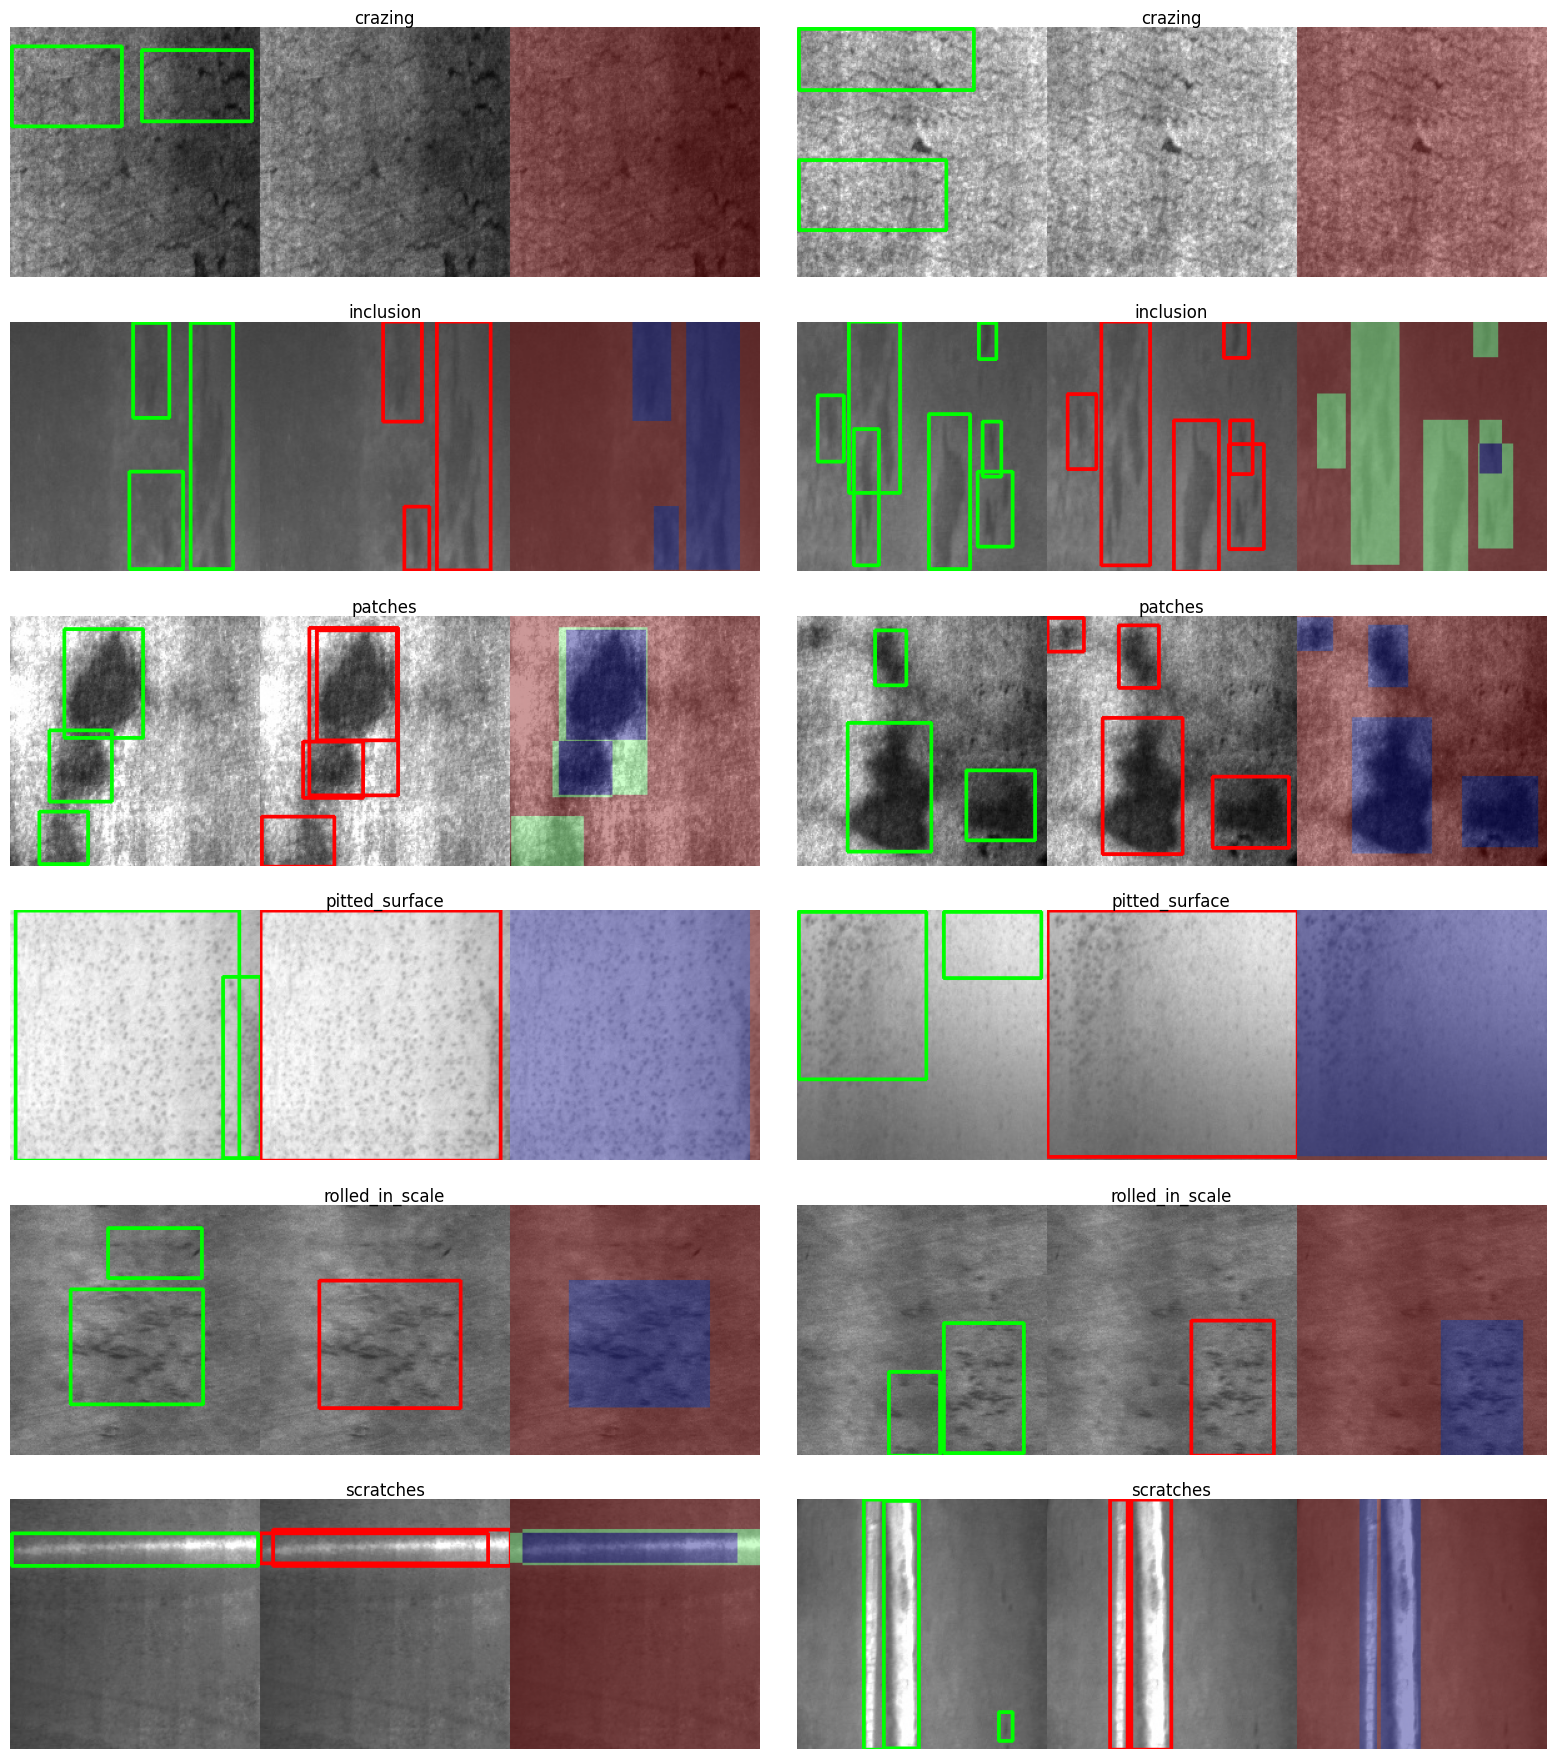

In [1]:
# =========================================================
# 🔥 STEP 1: REGISTER CUSTOM MODULES
# =========================================================
import sys
from pathlib import Path

PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()),
    None,
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.register_modules import register_custom_modules

register_custom_modules()

print("✅ Custom modules registered")


# =========================================================
# 📦 IMPORTS
# =========================================================
import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO


# =========================================================
# 📂 PATHS
# =========================================================
best_model_path = r"D:\MY Projects\Steel Defect Detection\runs\detect\experiments\SPDConv64__YOLO_v8n_480px_AdamW_cos_lr_100epochs_seed02\weights\best.pt"

data_root = (PROJECT_ROOT / "data/processed_v2").resolve()
data_yaml = (PROJECT_ROOT / "configs/data.yaml").resolve()

print("Model exists:", Path(best_model_path).exists())
print("Images exist:", (data_root / "images/test").exists())
print("Labels exist:", (data_root / "labels/test").exists())


# =========================================================
# 📦 LOAD LABELS
# =========================================================
def load_yolo_labels(label_path, w, h):
    boxes = []
    if not Path(label_path).exists():
        return boxes

    with open(label_path) as f:
        for line in f:
            cls, x, y, bw, bh = map(float, line.strip().split())
            x1 = int((x - bw / 2) * w)
            y1 = int((y - bh / 2) * h)
            x2 = int((x + bw / 2) * w)
            y2 = int((y + bh / 2) * h)
            boxes.append((int(cls), x1, y1, x2, y2))
    return boxes


# =========================================================
# 🎯 DRAW BOXES
# =========================================================
def draw_boxes(img, boxes, color, label):
    img = img.copy()
    for cls, x1, y1, x2, y2 in boxes:
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
    return img


# =========================================================
# 🔥 HEATMAP (ROBUST REPLACEMENT FOR GRAD-CAM)
# =========================================================
def generate_detection_heatmap(img, boxes):
    heatmap = np.zeros(img.shape[:2], dtype=np.float32)

    for _, x1, y1, x2, y2 in boxes:
        heatmap[y1:y2, x1:x2] += 1.0

    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()

    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    return cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)


# =========================================================
# 📸 SAMPLE SELECTION (DOMINANT CLASS)
# =========================================================
def get_samples(data_root, num_per_class=2):
    label_dir = data_root / "labels/test"
    image_dir = data_root / "images/test"

    samples = {i: [] for i in range(6)}

    for label_file in label_dir.glob("*.txt"):
        with open(label_file) as f:
            lines = f.readlines()

        if not lines:
            continue

        class_counts = {}
        for line in lines:
            cls = int(line.split()[0])
            class_counts[cls] = class_counts.get(cls, 0) + 1

        dominant_class = max(class_counts, key=class_counts.get)

        img = image_dir / (label_file.stem + ".jpg")
        if not img.exists():
            img = image_dir / (label_file.stem + ".png")

        if len(samples[dominant_class]) < num_per_class:
            samples[dominant_class].append(img)

    return samples


# =========================================================
# 🚀 MAIN VISUALIZATION
# =========================================================
def run_visualization():
    yolo = YOLO(best_model_path)

    names = yaml.safe_load(open(data_yaml))["names"]
    samples = get_samples(data_root)

    for k, v in samples.items():
        print(f"Class {k}: {len(v)} images")

    rows = len(names)
    cols = 2

    fig, axes = plt.subplots(rows, cols, figsize=(16, 3 * rows))
    for cls_id in range(rows):
        imgs = samples.get(cls_id, [])
        for col in range(cols):
            ax = axes[cls_id, col]

            if col >= len(imgs):
                ax.axis("off")
                continue

            img_path = imgs[col]

            img = cv2.imread(str(img_path))
            if img is None:
                ax.axis("off")
                continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w = img_rgb.shape[:2]

            # ---- GT ----
            gt_boxes = load_yolo_labels(
                str(img_path)
                .replace("images", "labels")
                .replace(".jpg", ".txt")
                .replace(".png", ".txt"),
                w,
                h,
            )
            gt_img = draw_boxes(img_rgb, gt_boxes, (0, 255, 0), "GT")

            # ---- Prediction ----
            results = yolo.predict(source=str(img_path), conf=0.25, verbose=False)[0]

            pred_boxes = []
            for b in results.boxes:
                cls = int(b.cls[0])
                x1, y1, x2, y2 = map(int, b.xyxy[0])
                pred_boxes.append((cls, x1, y1, x2, y2))

            pred_img = draw_boxes(img_rgb, pred_boxes, (255, 0, 0), "Pred")

            # ---- Heatmap ----
            cam_img = generate_detection_heatmap(img_rgb, pred_boxes)

            # ---- Combine ----
            combined = np.concatenate([gt_img, pred_img, cam_img], axis=1)

            ax.imshow(combined)
            ax.set_title(names[cls_id], fontsize=12, pad=2)
            ax.axis("off")

    # 🔥 REMOVE ALL EXTRA WHITE SPACE
    plt.subplots_adjust(
        left=0.02, right=0.98, top=0.98, bottom=0.02, hspace=0.15, wspace=0.05
    )

    plt.show()


# =========================================================
# ▶️ RUN
# =========================================================
run_visualization()


In [1]:
# =========================================================
# 📦 IMPORTS + SETUP
# =========================================================
import sys, os, random, time, gc
from pathlib import Path
import yaml
import torch
import pandas as pd

# ---------------------------------------------------------
# 🔥 PROJECT ROOT SETUP
# ---------------------------------------------------------
PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] 
     if (p / "src").exists() and (p / "configs").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Project root not found")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ---------------------------------------------------------
# 🔥 REGISTER CUSTOM MODULES
# ---------------------------------------------------------
import src
import ultralytics.nn.tasks as _tasks
import ultralytics.nn.modules as _modules

from src.custom_modules import M_C3k2, WeightedConcat, HybridSPDConv_3
from src.spd_conv import SPDConv, SPDHybrid, SPDHybrid_NO_Fuse

for name, cls in {
    "M_C3k2": M_C3k2,
    "WeightedConcat": WeightedConcat,
    "HybridSPDConv_3": HybridSPDConv_3,
    "SPDConv": SPDConv,
    "SPDHybrid": SPDHybrid,
    "SPDHybrid_NO_Fuse": SPDHybrid_NO_Fuse,
}.items():
    _tasks.__dict__[name] = cls
    _modules.__dict__[name] = cls

from ultralytics import YOLO


# =========================================================
# 🔁 SEED CONTROL
# =========================================================
def set_seed(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# =========================================================
# 📂 LOAD CONFIG
# =========================================================
def load_config():
    cfg_path = PROJECT_ROOT / "configs" / "base.yaml"
    with open(cfg_path, encoding="utf-8") as f:
        cfg = yaml.safe_load(f)

    cfg["model"] = str((PROJECT_ROOT / cfg["model"]).resolve())
    cfg["experiment"]["project_dir"] = str(
        (PROJECT_ROOT / cfg["experiment"]["project_dir"]).resolve()
    )
    cfg["data"]["config"] = str(
        (PROJECT_ROOT / cfg["data"]["config"]).resolve()
    )

    return cfg


# =========================================================
# 🚀 MAIN PIPELINE
# =========================================================
def run():
    cfg = load_config()

    model_name = cfg["model"]
    training = cfg["training"]
    experiment = cfg["experiment"]
    data_cfg = cfg["data"]["config"]

    seeds = experiment["seeds"]

    all_results = []

    print("\n🚀 Starting Experiments...\n")

    # =====================================
    # 🔁 LOOP OVER SEEDS
    # =====================================
    for seed in seeds:

        print(f"\n========== SEED {seed} ==========\n")

        set_seed(seed)

        exp_name = f"{experiment['name']}_seed{seed}"

        model = YOLO(model_name)

        # --------------------------
        # TRAIN
        # --------------------------
        start = time.time()

        results = model.train(
            data=data_cfg,
            imgsz=training["imgsz"],
            batch=training["batch"],
            epochs=training["epochs"],
            optimizer=training["optimizer"],
            lr0=training["lr0"],
            workers=training["workers"],
            seed=seed,
            project=experiment["project_dir"],
            name=exp_name,
        )

        train_time = (time.time() - start) / 60

        # --------------------------
        # TRAIN METRICS
        # --------------------------
        results_csv = Path(results.save_dir) / "results.csv"
        df = pd.read_csv(results_csv)

        map_col = "metrics/mAP50(B)" if "metrics/mAP50(B)" in df.columns else "metrics/mAP50"
        best_row = df.loc[df[map_col].idxmax()]

        best_weights = Path(results.save_dir) / "weights/best.pt"

        # --------------------------
        # VALIDATION
        # --------------------------
        val_results = model.val(data=data_cfg)

        val_map50 = val_results.box.map50
        val_precision = val_results.box.mp
        val_recall = val_results.box.mr

        speed = val_results.speed
        total_time = sum(speed.values())
        fps = 1000 / total_time if total_time > 0 else 0

        # --------------------------
        # TEST
        # --------------------------
        test_results = model.val(data=data_cfg, split="test")

        test_map50 = test_results.box.map50
        test_precision = test_results.box.mp
        test_recall = test_results.box.mr

        # --------------------------
        # STORE
        # --------------------------
        result = {
            "seed": seed,

            "train_mAP50": best_row.get("metrics/mAP50(B)", best_row.get("metrics/mAP50")),
            "train_precision": best_row.get("metrics/precision(B)", best_row.get("metrics/precision")),
            "train_recall": best_row.get("metrics/recall(B)", best_row.get("metrics/recall")),

            "val_mAP50": val_map50,
            "val_precision": val_precision,
            "val_recall": val_recall,

            "test_mAP50": test_map50,
            "test_precision": test_precision,
            "test_recall": test_recall,

            "fps": fps,
            "train_time_min": train_time,

            "weights": str(best_weights),
        }

        all_results.append(result)

        print("\n📊 Seed Results:")
        for k, v in result.items():
            if k != "weights":
                print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

        del model
        torch.cuda.empty_cache()
        gc.collect()

    # =====================================
    # 📊 FINAL TABLE
    # =====================================
    print("\n📊 ALL SEED RESULTS\n")

    df_results = pd.DataFrame(all_results)
    print(df_results.round(4))

    # =====================================
    # 🏆 BEST MODEL
    # =====================================
    best_exp = df_results.loc[df_results["test_mAP50"].idxmax()]

    print("\n🏆 BEST MODEL (TEST mAP50)\n")
    print(best_exp)

    # =====================================
    # 📈 AVERAGE PERFORMANCE
    # =====================================
    print("\n📈 AVERAGE PERFORMANCE\n")
    print(df_results.mean(numeric_only=True).round(4))

    # =====================================
    # 📊 PER-CLASS METRICS
    # =====================================
    print("\n📊 PER-CLASS PERFORMANCE (TEST SET)\n")

    best_model = YOLO(best_exp["weights"])

    test_results = best_model.val(data=data_cfg, split="test")

    names = test_results.names

    precision_cls = test_results.box.p
    recall_cls = test_results.box.r
    map50_cls = test_results.box.ap50

    class_metrics = []

    for i, name in names.items():
        class_metrics.append({
            "class": name,
            "precision": float(precision_cls[i]),
            "recall": float(recall_cls[i]),
            "mAP50": float(map50_cls[i]),
        })

    df_class = pd.DataFrame(class_metrics)
    df_class = df_class.sort_values(by="mAP50", ascending=False)

    print(df_class.round(4))

    print("\n✅ DONE\n")


# =========================================================
# ▶️ RUN
# =========================================================
run()


🚀 Starting Experiments...


========== SEED 0 ==========

New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.14  Python-3.11.0 torch-2.1.2+cu118 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\MY Projects\Steel Defect Detection\configs\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.

In [2]:
# =========================================================
# 📦 IMPORTS + SETUP
# =========================================================
import sys, os, random, time, gc
from pathlib import Path
import yaml
import torch
import pandas as pd

# ---------------------------------------------------------
# 🔥 PROJECT ROOT SETUP
# ---------------------------------------------------------
PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] 
     if (p / "src").exists() and (p / "configs").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Project root not found")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ---------------------------------------------------------
# 🔥 REGISTER CUSTOM MODULES
# ---------------------------------------------------------
import src
import ultralytics.nn.tasks as _tasks
import ultralytics.nn.modules as _modules

from src.custom_modules import M_C3k2, WeightedConcat, HybridSPDConv_3
from src.spd_conv import SPDConv, SPDHybrid, SPDHybrid_NO_Fuse

for name, cls in {
    "M_C3k2": M_C3k2,
    "WeightedConcat": WeightedConcat,
    "HybridSPDConv_3": HybridSPDConv_3,
    "SPDConv": SPDConv,
    "SPDHybrid": SPDHybrid,
    "SPDHybrid_NO_Fuse": SPDHybrid_NO_Fuse,
}.items():
    _tasks.__dict__[name] = cls
    _modules.__dict__[name] = cls

from ultralytics import YOLO


# =========================================================
# 🔁 SEED CONTROL
# =========================================================
def set_seed(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# =========================================================
# 📂 LOAD CONFIG
# =========================================================
def load_config():
    cfg_path = PROJECT_ROOT / "configs" / "base.yaml"
    with open(cfg_path, encoding="utf-8") as f:
        cfg = yaml.safe_load(f)

    cfg["model"] = str((PROJECT_ROOT / cfg["model"]).resolve())
    cfg["experiment"]["project_dir"] = str(
        (PROJECT_ROOT / cfg["experiment"]["project_dir"]).resolve()
    )
    cfg["data"]["config"] = str(
        (PROJECT_ROOT / cfg["data"]["config"]).resolve()
    )

    return cfg


# =========================================================
# 🚀 MAIN PIPELINE
# =========================================================
def run():
    cfg = load_config()

    model_name = cfg["model"]
    training = cfg["training"]
    experiment = cfg["experiment"]
    data_cfg = cfg["data"]["config"]

    seeds = experiment["seeds"]

    all_results = []

    print("\n🚀 Starting Experiments...\n")

    # =====================================
    # 🔁 LOOP OVER SEEDS
    # =====================================
    for seed in seeds:

        print(f"\n========== SEED {seed} ==========\n")

        set_seed(seed)

        exp_name = f"{experiment['name']}_seed{seed}"

        model = YOLO(model_name)

        # --------------------------
        # TRAIN
        # --------------------------
        start = time.time()

        results = model.train(
            data=data_cfg,
            imgsz=training["imgsz"],
            batch=training["batch"],
            epochs=training["epochs"],
            optimizer=training["optimizer"],
            lr0=training["lr0"],
            workers=training["workers"],
            seed=seed,
            project=experiment["project_dir"],
            name=exp_name,
        )

        train_time = (time.time() - start) / 60

        # --------------------------
        # TRAIN METRICS
        # --------------------------
        results_csv = Path(results.save_dir) / "results.csv"
        df = pd.read_csv(results_csv)

        map_col = "metrics/mAP50(B)" if "metrics/mAP50(B)" in df.columns else "metrics/mAP50"
        best_row = df.loc[df[map_col].idxmax()]

        best_weights = Path(results.save_dir) / "weights/best.pt"

        # --------------------------
        # VALIDATION
        # --------------------------
        val_results = model.val(data=data_cfg)

        val_map50 = val_results.box.map50
        val_precision = val_results.box.mp
        val_recall = val_results.box.mr

        speed = val_results.speed
        total_time = sum(speed.values())
        fps = 1000 / total_time if total_time > 0 else 0

        # --------------------------
        # TEST
        # --------------------------
        test_results = model.val(data=data_cfg, split="test")

        test_map50 = test_results.box.map50
        test_precision = test_results.box.mp
        test_recall = test_results.box.mr

        # --------------------------
        # STORE
        # --------------------------
        result = {
            "seed": seed,

            "train_mAP50": best_row.get("metrics/mAP50(B)", best_row.get("metrics/mAP50")),
            "train_precision": best_row.get("metrics/precision(B)", best_row.get("metrics/precision")),
            "train_recall": best_row.get("metrics/recall(B)", best_row.get("metrics/recall")),

            "val_mAP50": val_map50,
            "val_precision": val_precision,
            "val_recall": val_recall,

            "test_mAP50": test_map50,
            "test_precision": test_precision,
            "test_recall": test_recall,

            "fps": fps,
            "train_time_min": train_time,

            "weights": str(best_weights),
        }

        all_results.append(result)

        print("\n📊 Seed Results:")
        for k, v in result.items():
            if k != "weights":
                print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

        del model
        torch.cuda.empty_cache()
        gc.collect()

    # =====================================
    # 📊 FINAL TABLE
    # =====================================
    print("\n📊 ALL SEED RESULTS\n")

    df_results = pd.DataFrame(all_results)
    print(df_results.round(4))

    # =====================================
    # 🏆 BEST MODEL
    # =====================================
    best_exp = df_results.loc[df_results["test_mAP50"].idxmax()]

    print("\n🏆 BEST MODEL (TEST mAP50)\n")
    print(best_exp)

    # =====================================
    # 📈 AVERAGE PERFORMANCE
    # =====================================
    print("\n📈 AVERAGE PERFORMANCE\n")
    print(df_results.mean(numeric_only=True).round(4))

    # =====================================
    # 📊 PER-CLASS METRICS
    # =====================================
    print("\n📊 PER-CLASS PERFORMANCE (TEST SET)\n")

    best_model = YOLO(best_exp["weights"])

    test_results = best_model.val(data=data_cfg, split="test")

    names = test_results.names

    precision_cls = test_results.box.p
    recall_cls = test_results.box.r
    map50_cls = test_results.box.ap50

    class_metrics = []

    for i, name in names.items():
        class_metrics.append({
            "class": name,
            "precision": float(precision_cls[i]),
            "recall": float(recall_cls[i]),
            "mAP50": float(map50_cls[i]),
        })

    df_class = pd.DataFrame(class_metrics)
    df_class = df_class.sort_values(by="mAP50", ascending=False)

    print(df_class.round(4))

    print("\n✅ DONE\n")


# =========================================================
# ▶️ RUN
# =========================================================
run()


🚀 Starting Experiments...


========== SEED 0 ==========

WARNING no model scale passed. Assuming scale='n'.
New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.14  Python-3.11.0 torch-2.1.2+cu118 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\MY Projects\Steel Defect Detection\configs\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0

In [1]:
# =========================================================
# 📦 IMPORTS + SETUP
# =========================================================
import sys, os, random, time, gc
from pathlib import Path
import yaml
import torch
import pandas as pd

# ---------------------------------------------------------
# 🔥 PROJECT ROOT SETUP
# ---------------------------------------------------------
PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] 
     if (p / "src").exists() and (p / "configs").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Project root not found")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ---------------------------------------------------------
# 🔥 REGISTER CUSTOM MODULES
# ---------------------------------------------------------
import src
import ultralytics.nn.tasks as _tasks
import ultralytics.nn.modules as _modules

from src.custom_modules import M_C3k2, WeightedConcat, HybridSPDConv_3
from src.spd_conv import SPDConv, SPDHybrid, SPDHybrid_NO_Fuse

for name, cls in {
    "M_C3k2": M_C3k2,
    "WeightedConcat": WeightedConcat,
    "HybridSPDConv_3": HybridSPDConv_3,
    "SPDConv": SPDConv,
    "SPDHybrid": SPDHybrid,
    "SPDHybrid_NO_Fuse": SPDHybrid_NO_Fuse,
}.items():
    _tasks.__dict__[name] = cls
    _modules.__dict__[name] = cls

from ultralytics import YOLO


# =========================================================
# 🔁 SEED CONTROL
# =========================================================
def set_seed(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# =========================================================
# 📂 LOAD CONFIG
# =========================================================
def load_config():
    cfg_path = PROJECT_ROOT / "configs" / "base.yaml"
    with open(cfg_path, encoding="utf-8") as f:
        cfg = yaml.safe_load(f)

    cfg["model"] = str((PROJECT_ROOT / cfg["model"]).resolve())
    cfg["experiment"]["project_dir"] = str(
        (PROJECT_ROOT / cfg["experiment"]["project_dir"]).resolve()
    )
    cfg["data"]["config"] = str(
        (PROJECT_ROOT / cfg["data"]["config"]).resolve()
    )

    return cfg


# =========================================================
# 🚀 MAIN PIPELINE
# =========================================================
def run():
    cfg = load_config()

    model_name = cfg["model"]
    training = cfg["training"]
    experiment = cfg["experiment"]
    data_cfg = cfg["data"]["config"]

    seeds = experiment["seeds"]

    all_results = []

    print("\n🚀 Starting Experiments...\n")

    # =====================================
    # 🔁 LOOP OVER SEEDS
    # =====================================
    for seed in seeds:

        print(f"\n========== SEED {seed} ==========\n")

        set_seed(seed)

        exp_name = f"{experiment['name']}_seed{seed}"

        model = YOLO(model_name)

        # --------------------------
        # TRAIN
        # --------------------------
        start = time.time()

        results = model.train(
            data=data_cfg,
            imgsz=training["imgsz"],
            batch=training["batch"],
            epochs=training["epochs"],
            optimizer=training["optimizer"],
            lr0=training["lr0"],
            workers=training["workers"],
            seed=seed,
            project=experiment["project_dir"],
            name=exp_name,
        )

        train_time = (time.time() - start) / 60

        # --------------------------
        # TRAIN METRICS
        # --------------------------
        results_csv = Path(results.save_dir) / "results.csv"
        df = pd.read_csv(results_csv)

        map_col = "metrics/mAP50(B)" if "metrics/mAP50(B)" in df.columns else "metrics/mAP50"
        best_row = df.loc[df[map_col].idxmax()]

        best_weights = Path(results.save_dir) / "weights/best.pt"

        # --------------------------
        # VALIDATION
        # --------------------------
        val_results = model.val(data=data_cfg)

        val_map50 = val_results.box.map50
        val_precision = val_results.box.mp
        val_recall = val_results.box.mr

        speed = val_results.speed
        total_time = sum(speed.values())
        fps = 1000 / total_time if total_time > 0 else 0

        # --------------------------
        # TEST
        # --------------------------
        test_results = model.val(data=data_cfg, split="test")

        test_map50 = test_results.box.map50
        test_precision = test_results.box.mp
        test_recall = test_results.box.mr

        # --------------------------
        # STORE
        # --------------------------
        result = {
            "seed": seed,

            "train_mAP50": best_row.get("metrics/mAP50(B)", best_row.get("metrics/mAP50")),
            "train_precision": best_row.get("metrics/precision(B)", best_row.get("metrics/precision")),
            "train_recall": best_row.get("metrics/recall(B)", best_row.get("metrics/recall")),

            "val_mAP50": val_map50,
            "val_precision": val_precision,
            "val_recall": val_recall,

            "test_mAP50": test_map50,
            "test_precision": test_precision,
            "test_recall": test_recall,

            "fps": fps,
            "train_time_min": train_time,

            "weights": str(best_weights),
        }

        all_results.append(result)

        print("\n📊 Seed Results:")
        for k, v in result.items():
            if k != "weights":
                print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

        del model
        torch.cuda.empty_cache()
        gc.collect()

    # =====================================
    # 📊 FINAL TABLE
    # =====================================
    print("\n📊 ALL SEED RESULTS\n")

    df_results = pd.DataFrame(all_results)
    print(df_results.round(4))

    # =====================================
    # 🏆 BEST MODEL
    # =====================================
    best_exp = df_results.loc[df_results["test_mAP50"].idxmax()]

    print("\n🏆 BEST MODEL (TEST mAP50)\n")
    print(best_exp)

    # =====================================
    # 📈 AVERAGE PERFORMANCE
    # =====================================
    print("\n📈 AVERAGE PERFORMANCE\n")
    print(df_results.mean(numeric_only=True).round(4))

    # =====================================
    # 📊 PER-CLASS METRICS
    # =====================================
    print("\n📊 PER-CLASS PERFORMANCE (TEST SET)\n")

    best_model = YOLO(best_exp["weights"])

    test_results = best_model.val(data=data_cfg, split="test")

    names = test_results.names

    precision_cls = test_results.box.p
    recall_cls = test_results.box.r
    map50_cls = test_results.box.ap50

    class_metrics = []

    for i, name in names.items():
        class_metrics.append({
            "class": name,
            "precision": float(precision_cls[i]),
            "recall": float(recall_cls[i]),
            "mAP50": float(map50_cls[i]),
        })

    df_class = pd.DataFrame(class_metrics)
    df_class = df_class.sort_values(by="mAP50", ascending=False)

    print(df_class.round(4))

    print("\n✅ DONE\n")


# =========================================================
# ▶️ RUN
# =========================================================
run()


🚀 Starting Experiments...


========== SEED 0 ==========

New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.14  Python-3.11.0 torch-2.1.2+cu118 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\MY Projects\Steel Defect Detection\configs\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.

✅ Custom modules registered
Model exists: True
Images exist: True
Labels exist: True
Class 0: 2 images
Class 1: 2 images
Class 2: 2 images
Class 3: 2 images
Class 4: 2 images
Class 5: 2 images


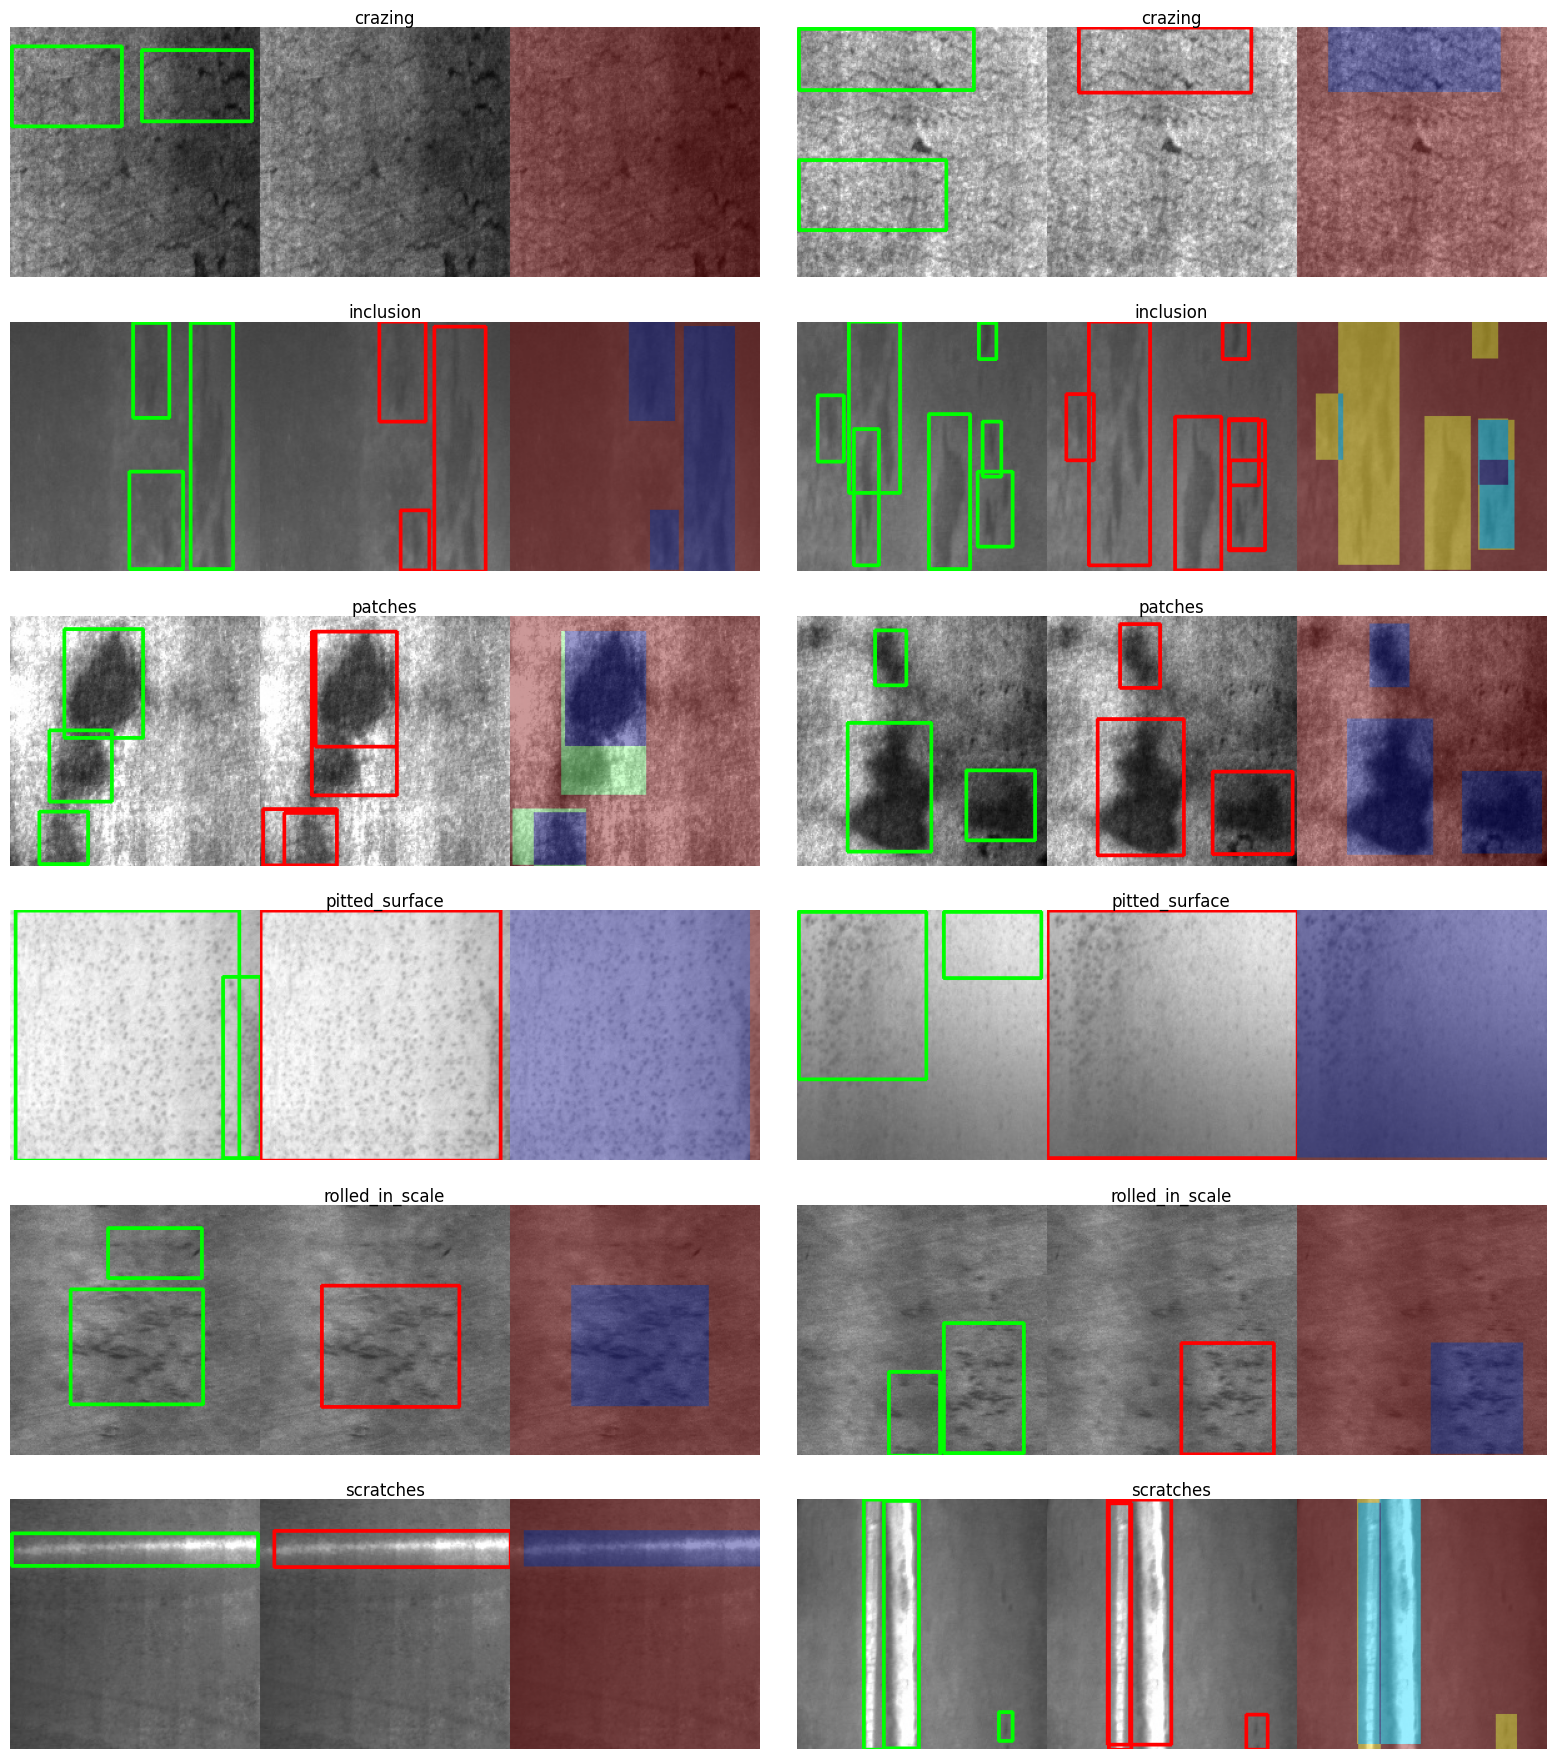

In [1]:
# =========================================================
# 🔥 STEP 1: REGISTER CUSTOM MODULES
# =========================================================
import sys
from pathlib import Path

PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()),
    None,
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.register_modules import register_custom_modules

register_custom_modules()

print("✅ Custom modules registered")


# =========================================================
# 📦 IMPORTS
# =========================================================
import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO


# =========================================================
# 📂 PATHS
# =========================================================
best_model_path = r"D:\MY Projects\Steel Defect Detection\runs\detect\experiments\Full_SPDHybrid_with_Fuse_YOLO_v8n_480px_AdamW_cos_lr_150epochs_seed0\weights\best.pt"

data_root = (PROJECT_ROOT / "data/processed_v2").resolve()
data_yaml = (PROJECT_ROOT / "configs/data.yaml").resolve()

print("Model exists:", Path(best_model_path).exists())
print("Images exist:", (data_root / "images/test").exists())
print("Labels exist:", (data_root / "labels/test").exists())


# =========================================================
# 📦 LOAD LABELS
# =========================================================
def load_yolo_labels(label_path, w, h):
    boxes = []
    if not Path(label_path).exists():
        return boxes

    with open(label_path) as f:
        for line in f:
            cls, x, y, bw, bh = map(float, line.strip().split())
            x1 = int((x - bw / 2) * w)
            y1 = int((y - bh / 2) * h)
            x2 = int((x + bw / 2) * w)
            y2 = int((y + bh / 2) * h)
            boxes.append((int(cls), x1, y1, x2, y2))
    return boxes


# =========================================================
# 🎯 DRAW BOXES
# =========================================================
def draw_boxes(img, boxes, color, label):
    img = img.copy()
    for cls, x1, y1, x2, y2 in boxes:
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
    return img


# =========================================================
# 🔥 HEATMAP (ROBUST REPLACEMENT FOR GRAD-CAM)
# =========================================================
def generate_detection_heatmap(img, boxes):
    heatmap = np.zeros(img.shape[:2], dtype=np.float32)

    for _, x1, y1, x2, y2 in boxes:
        heatmap[y1:y2, x1:x2] += 1.0

    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()

    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    return cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)


# =========================================================
# 📸 SAMPLE SELECTION (DOMINANT CLASS)
# =========================================================
def get_samples(data_root, num_per_class=2):
    label_dir = data_root / "labels/test"
    image_dir = data_root / "images/test"

    samples = {i: [] for i in range(6)}

    for label_file in label_dir.glob("*.txt"):
        with open(label_file) as f:
            lines = f.readlines()

        if not lines:
            continue

        class_counts = {}
        for line in lines:
            cls = int(line.split()[0])
            class_counts[cls] = class_counts.get(cls, 0) + 1

        dominant_class = max(class_counts, key=class_counts.get)

        img = image_dir / (label_file.stem + ".jpg")
        if not img.exists():
            img = image_dir / (label_file.stem + ".png")

        if len(samples[dominant_class]) < num_per_class:
            samples[dominant_class].append(img)

    return samples


# =========================================================
# 🚀 MAIN VISUALIZATION
# =========================================================
def run_visualization():
    yolo = YOLO(best_model_path)

    names = yaml.safe_load(open(data_yaml))["names"]
    samples = get_samples(data_root)

    for k, v in samples.items():
        print(f"Class {k}: {len(v)} images")

    rows = len(names)
    cols = 2

    fig, axes = plt.subplots(rows, cols, figsize=(16, 3 * rows))
    for cls_id in range(rows):
        imgs = samples.get(cls_id, [])
        for col in range(cols):
            ax = axes[cls_id, col]

            if col >= len(imgs):
                ax.axis("off")
                continue

            img_path = imgs[col]

            img = cv2.imread(str(img_path))
            if img is None:
                ax.axis("off")
                continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w = img_rgb.shape[:2]

            # ---- GT ----
            gt_boxes = load_yolo_labels(
                str(img_path)
                .replace("images", "labels")
                .replace(".jpg", ".txt")
                .replace(".png", ".txt"),
                w,
                h,
            )
            gt_img = draw_boxes(img_rgb, gt_boxes, (0, 255, 0), "GT")

            # ---- Prediction ----
            results = yolo.predict(source=str(img_path), conf=0.25, verbose=False)[0]

            pred_boxes = []
            for b in results.boxes:
                cls = int(b.cls[0])
                x1, y1, x2, y2 = map(int, b.xyxy[0])
                pred_boxes.append((cls, x1, y1, x2, y2))

            pred_img = draw_boxes(img_rgb, pred_boxes, (255, 0, 0), "Pred")

            # ---- Heatmap ----
            cam_img = generate_detection_heatmap(img_rgb, pred_boxes)

            # ---- Combine ----
            combined = np.concatenate([gt_img, pred_img, cam_img], axis=1)

            ax.imshow(combined)
            ax.set_title(names[cls_id], fontsize=12, pad=2)
            ax.axis("off")

    # 🔥 REMOVE ALL EXTRA WHITE SPACE
    plt.subplots_adjust(
        left=0.02, right=0.98, top=0.98, bottom=0.02, hspace=0.15, wspace=0.05
    )

    plt.show()


# =========================================================
# ▶️ RUN
# =========================================================
run_visualization()


In [1]:
# =========================================================
# 📦 IMPORTS + SETUP
# =========================================================
import sys, os, random, time, gc
from pathlib import Path
import yaml
import torch
import pandas as pd

# ---------------------------------------------------------
# 🔥 PROJECT ROOT SETUP
# ---------------------------------------------------------
PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] 
     if (p / "src").exists() and (p / "configs").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Project root not found")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ---------------------------------------------------------
# 🔥 REGISTER CUSTOM MODULES
# ---------------------------------------------------------
import src
import ultralytics.nn.tasks as _tasks
import ultralytics.nn.modules as _modules

from src.custom_modules import M_C3k2, WeightedConcat, HybridSPDConv_3
from src.spd_conv import SPDConv, SPDHybrid, SPDHybrid_NO_Fuse

for name, cls in {
    "M_C3k2": M_C3k2,
    "WeightedConcat": WeightedConcat,
    "HybridSPDConv_3": HybridSPDConv_3,
    "SPDConv": SPDConv,
    "SPDHybrid": SPDHybrid,
    "SPDHybrid_NO_Fuse": SPDHybrid_NO_Fuse,
}.items():
    _tasks.__dict__[name] = cls
    _modules.__dict__[name] = cls

from ultralytics import YOLO


# =========================================================
# 🔁 SEED CONTROL
# =========================================================
def set_seed(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# =========================================================
# 📂 LOAD CONFIG
# =========================================================
def load_config():
    cfg_path = PROJECT_ROOT / "configs" / "base.yaml"
    with open(cfg_path, encoding="utf-8") as f:
        cfg = yaml.safe_load(f)

    cfg["model"] = str((PROJECT_ROOT / cfg["model"]).resolve())
    cfg["experiment"]["project_dir"] = str(
        (PROJECT_ROOT / cfg["experiment"]["project_dir"]).resolve()
    )
    cfg["data"]["config"] = str(
        (PROJECT_ROOT / cfg["data"]["config"]).resolve()
    )

    return cfg


# =========================================================
# 🚀 MAIN PIPELINE
# =========================================================
def run():
    cfg = load_config()

    model_name = cfg["model"]
    training = cfg["training"]
    experiment = cfg["experiment"]
    data_cfg = cfg["data"]["config"]

    seeds = experiment["seeds"]

    all_results = []

    print("\n🚀 Starting Experiments...\n")

    # =====================================
    # 🔁 LOOP OVER SEEDS
    # =====================================
    for seed in seeds:

        print(f"\n========== SEED {seed} ==========\n")

        set_seed(seed)

        exp_name = f"{experiment['name']}_seed{seed}"

        model = YOLO(model_name)

        # --------------------------
        # TRAIN
        # --------------------------
        start = time.time()

        results = model.train(
            data=data_cfg,
            imgsz=training["imgsz"],
            batch=training["batch"],
            epochs=training["epochs"],
            optimizer=training["optimizer"],
            lr0=training["lr0"],
            workers=training["workers"],
            seed=seed,
            project=experiment["project_dir"],
            name=exp_name,
        )

        train_time = (time.time() - start) / 60

        # --------------------------
        # TRAIN METRICS
        # --------------------------
        results_csv = Path(results.save_dir) / "results.csv"
        df = pd.read_csv(results_csv)

        map_col = "metrics/mAP50(B)" if "metrics/mAP50(B)" in df.columns else "metrics/mAP50"
        best_row = df.loc[df[map_col].idxmax()]

        best_weights = Path(results.save_dir) / "weights/best.pt"

        # --------------------------
        # VALIDATION
        # --------------------------
        val_results = model.val(data=data_cfg)

        val_map50 = val_results.box.map50
        val_precision = val_results.box.mp
        val_recall = val_results.box.mr

        speed = val_results.speed
        total_time = sum(speed.values())
        fps = 1000 / total_time if total_time > 0 else 0

        # --------------------------
        # TEST
        # --------------------------
        test_results = model.val(data=data_cfg, split="test")

        test_map50 = test_results.box.map50
        test_precision = test_results.box.mp
        test_recall = test_results.box.mr

        # --------------------------
        # STORE
        # --------------------------
        result = {
            "seed": seed,

            "train_mAP50": best_row.get("metrics/mAP50(B)", best_row.get("metrics/mAP50")),
            "train_precision": best_row.get("metrics/precision(B)", best_row.get("metrics/precision")),
            "train_recall": best_row.get("metrics/recall(B)", best_row.get("metrics/recall")),

            "val_mAP50": val_map50,
            "val_precision": val_precision,
            "val_recall": val_recall,

            "test_mAP50": test_map50,
            "test_precision": test_precision,
            "test_recall": test_recall,

            "fps": fps,
            "train_time_min": train_time,

            "weights": str(best_weights),
        }

        all_results.append(result)

        print("\n📊 Seed Results:")
        for k, v in result.items():
            if k != "weights":
                print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

        del model
        torch.cuda.empty_cache()
        gc.collect()

    # =====================================
    # 📊 FINAL TABLE
    # =====================================
    print("\n📊 ALL SEED RESULTS\n")

    df_results = pd.DataFrame(all_results)
    print(df_results.round(4))

    # =====================================
    # 🏆 BEST MODEL
    # =====================================
    best_exp = df_results.loc[df_results["test_mAP50"].idxmax()]

    print("\n🏆 BEST MODEL (TEST mAP50)\n")
    print(best_exp)

    # =====================================
    # 📈 AVERAGE PERFORMANCE
    # =====================================
    print("\n📈 AVERAGE PERFORMANCE\n")
    print(df_results.mean(numeric_only=True).round(4))

    # =====================================
    # 📊 PER-CLASS METRICS
    # =====================================
    print("\n📊 PER-CLASS PERFORMANCE (TEST SET)\n")

    best_model = YOLO(best_exp["weights"])

    test_results = best_model.val(data=data_cfg, split="test")

    names = test_results.names

    precision_cls = test_results.box.p
    recall_cls = test_results.box.r
    map50_cls = test_results.box.ap50

    class_metrics = []

    for i, name in names.items():
        class_metrics.append({
            "class": name,
            "precision": float(precision_cls[i]),
            "recall": float(recall_cls[i]),
            "mAP50": float(map50_cls[i]),
        })

    df_class = pd.DataFrame(class_metrics)
    df_class = df_class.sort_values(by="mAP50", ascending=False)

    print(df_class.round(4))

    print("\n✅ DONE\n")


# =========================================================
# ▶️ RUN
# =========================================================
run()


🚀 Starting Experiments...


========== SEED 0 ==========

WARNING no model scale passed. Assuming scale='n'.
New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.14  Python-3.11.0 torch-2.1.2+cu118 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\MY Projects\Steel Defect Detection\configs\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0

In [ ]:
# ==============YOLOv8_F_SPDHY_Fused_Neck===========================================
# 📦 IMPORTS + SETUP
# =========================================================
import sys, os, random, time, gc
from pathlib import Path
import yaml
import torch
import pandas as pd

# ---------------------------------------------------------
# 🔥 PROJECT ROOT SETUP
# ---------------------------------------------------------
PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] 
     if (p / "src").exists() and (p / "configs").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Project root not found")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ---------------------------------------------------------
# 🔥 REGISTER CUSTOM MODULES
# ---------------------------------------------------------
import src
import ultralytics.nn.tasks as _tasks
import ultralytics.nn.modules as _modules

from src.custom_modules import M_C3k2, WeightedConcat, HybridSPDConv_3
from src.spd_conv import SPDConv, SPDHybrid, SPDHybrid_NO_Fuse

for name, cls in {
    "M_C3k2": M_C3k2,
    "WeightedConcat": WeightedConcat,
    "HybridSPDConv_3": HybridSPDConv_3,
    "SPDConv": SPDConv,
    "SPDHybrid": SPDHybrid,
    "SPDHybrid_NO_Fuse": SPDHybrid_NO_Fuse,
}.items():
    _tasks.__dict__[name] = cls
    _modules.__dict__[name] = cls

from ultralytics import YOLO


# =========================================================
# 🔁 SEED CONTROL
# =========================================================
def set_seed(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# =========================================================
# 📂 LOAD CONFIG
# =========================================================
def load_config():
    cfg_path = PROJECT_ROOT / "configs" / "base.yaml"
    with open(cfg_path, encoding="utf-8") as f:
        cfg = yaml.safe_load(f)

    cfg["model"] = str((PROJECT_ROOT / cfg["model"]).resolve())
    cfg["experiment"]["project_dir"] = str(
        (PROJECT_ROOT / cfg["experiment"]["project_dir"]).resolve()
    )
    cfg["data"]["config"] = str(
        (PROJECT_ROOT / cfg["data"]["config"]).resolve()
    )

    return cfg


# =========================================================
# 🚀 MAIN PIPELINE
# =========================================================
def run():
    cfg = load_config()

    model_name = cfg["model"]
    training = cfg["training"]
    experiment = cfg["experiment"]
    data_cfg = cfg["data"]["config"]

    seeds = experiment["seeds"]

    all_results = []

    print("\n🚀 Starting Experiments...\n")

    # =====================================
    # 🔁 LOOP OVER SEEDS
    # =====================================
    for seed in seeds:

        print(f"\n========== SEED {seed} ==========\n")

        set_seed(seed)

        exp_name = f"{experiment['name']}_seed{seed}"

        model = YOLO(model_name)

        # --------------------------
        # TRAIN
        # --------------------------
        start = time.time()

        results = model.train(
            data=data_cfg,
            imgsz=training["imgsz"],
            batch=training["batch"],
            epochs=training["epochs"],
            optimizer=training["optimizer"],
            lr0=training["lr0"],
            workers=training["workers"],
            seed=seed,
            project=experiment["project_dir"],
            name=exp_name,
        )

        train_time = (time.time() - start) / 60

        # --------------------------
        # TRAIN METRICS
        # --------------------------
        results_csv = Path(results.save_dir) / "results.csv"
        df = pd.read_csv(results_csv)

        map_col = "metrics/mAP50(B)" if "metrics/mAP50(B)" in df.columns else "metrics/mAP50"
        best_row = df.loc[df[map_col].idxmax()]

        best_weights = Path(results.save_dir) / "weights/best.pt"

        # --------------------------
        # VALIDATION
        # --------------------------
        val_results = model.val(data=data_cfg)

        val_map50 = val_results.box.map50
        val_precision = val_results.box.mp
        val_recall = val_results.box.mr

        speed = val_results.speed
        total_time = sum(speed.values())
        fps = 1000 / total_time if total_time > 0 else 0

        # --------------------------
        # TEST
        # --------------------------
        test_results = model.val(data=data_cfg, split="test")

        test_map50 = test_results.box.map50
        test_precision = test_results.box.mp
        test_recall = test_results.box.mr

        # --------------------------
        # STORE
        # --------------------------
        result = {
            "seed": seed,

            "train_mAP50": best_row.get("metrics/mAP50(B)", best_row.get("metrics/mAP50")),
            "train_precision": best_row.get("metrics/precision(B)", best_row.get("metrics/precision")),
            "train_recall": best_row.get("metrics/recall(B)", best_row.get("metrics/recall")),

            "val_mAP50": val_map50,
            "val_precision": val_precision,
            "val_recall": val_recall,

            "test_mAP50": test_map50,
            "test_precision": test_precision,
            "test_recall": test_recall,

            "fps": fps,
            "train_time_min": train_time,

            "weights": str(best_weights),
        }

        all_results.append(result)

        print("\n📊 Seed Results:")
        for k, v in result.items():
            if k != "weights":
                print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

        del model
        torch.cuda.empty_cache()
        gc.collect()

    # =====================================
    # 📊 FINAL TABLE
    # =====================================
    print("\n📊 ALL SEED RESULTS\n")

    df_results = pd.DataFrame(all_results)
    print(df_results.round(4))

    # =====================================
    # 🏆 BEST MODEL
    # =====================================
    best_exp = df_results.loc[df_results["test_mAP50"].idxmax()]

    print("\n🏆 BEST MODEL (TEST mAP50)\n")
    print(best_exp)

    # =====================================
    # 📈 AVERAGE PERFORMANCE
    # =====================================
    print("\n📈 AVERAGE PERFORMANCE\n")
    print(df_results.mean(numeric_only=True).round(4))

    # =====================================
    # 📊 PER-CLASS METRICS
    # =====================================
    print("\n📊 PER-CLASS PERFORMANCE (TEST SET)\n")

    best_model = YOLO(best_exp["weights"])

    test_results = best_model.val(data=data_cfg, split="test")

    names = test_results.names

    precision_cls = test_results.box.p
    recall_cls = test_results.box.r
    map50_cls = test_results.box.ap50

    class_metrics = []

    for i, name in names.items():
        class_metrics.append({
            "class": name,
            "precision": float(precision_cls[i]),
            "recall": float(recall_cls[i]),
            "mAP50": float(map50_cls[i]),
        })

    df_class = pd.DataFrame(class_metrics)
    df_class = df_class.sort_values(by="mAP50", ascending=False)

    print(df_class.round(4))

    print("\n✅ DONE\n")


# =========================================================
# ▶️ RUN
# =========================================================
run()


🚀 Starting Experiments...


========== SEED 0 ==========

WARNING no model scale passed. Assuming scale='n'.
New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.14  Python-3.11.0 torch-2.1.2+cu118 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\MY Projects\Steel Defect Detection\configs\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0

In [ ]:
# ==========src.spd_SPDHybrid + C3k2===============================================
# 📦 IMPORTS + SETUP
# =========================================================
import sys, os, random, time, gc
from pathlib import Path
import yaml
import torch
import pandas as pd

# ---------------------------------------------------------
# 🔥 PROJECT ROOT SETUP
# ---------------------------------------------------------
PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] 
     if (p / "src").exists() and (p / "configs").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Project root not found")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ---------------------------------------------------------
# 🔥 REGISTER CUSTOM MODULES
# ---------------------------------------------------------
import src
import ultralytics.nn.tasks as _tasks
import ultralytics.nn.modules as _modules

from src.custom_modules import M_C3k2, WeightedConcat, HybridSPDConv_3
from src.spd_conv import SPDConv, SPDHybrid, SPDHybrid_NO_Fuse

for name, cls in {
    "M_C3k2": M_C3k2,
    "WeightedConcat": WeightedConcat,
    "HybridSPDConv_3": HybridSPDConv_3,
    "SPDConv": SPDConv,
    "SPDHybrid": SPDHybrid,
    "SPDHybrid_NO_Fuse": SPDHybrid_NO_Fuse,
}.items():
    _tasks.__dict__[name] = cls
    _modules.__dict__[name] = cls

from ultralytics import YOLO


# =========================================================
# 🔁 SEED CONTROL
# =========================================================
def set_seed(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# =========================================================
# 📂 LOAD CONFIG
# =========================================================
def load_config():
    cfg_path = PROJECT_ROOT / "configs" / "base.yaml"
    with open(cfg_path, encoding="utf-8") as f:
        cfg = yaml.safe_load(f)

    cfg["model"] = str((PROJECT_ROOT / cfg["model"]).resolve())
    cfg["experiment"]["project_dir"] = str(
        (PROJECT_ROOT / cfg["experiment"]["project_dir"]).resolve()
    )
    cfg["data"]["config"] = str(
        (PROJECT_ROOT / cfg["data"]["config"]).resolve()
    )

    return cfg


# =========================================================
# 🚀 MAIN PIPELINE
# =========================================================
def run():
    cfg = load_config()

    model_name = cfg["model"]
    training = cfg["training"]
    experiment = cfg["experiment"]
    data_cfg = cfg["data"]["config"]

    seeds = experiment["seeds"]

    all_results = []

    print("\n🚀 Starting Experiments...\n")

    # =====================================
    # 🔁 LOOP OVER SEEDS
    # =====================================
    for seed in seeds:

        print(f"\n========== SEED {seed} ==========\n")

        set_seed(seed)

        exp_name = f"{experiment['name']}_seed{seed}"

        model = YOLO(model_name)

        # --------------------------
        # TRAIN
        # --------------------------
        start = time.time()

        results = model.train(
            data=data_cfg,
            imgsz=training["imgsz"],
            batch=training["batch"],
            epochs=training["epochs"],
            optimizer=training["optimizer"],
            lr0=training["lr0"],
            workers=training["workers"],
            seed=seed,
            project=experiment["project_dir"],
            name=exp_name,
        )

        train_time = (time.time() - start) / 60

        # --------------------------
        # TRAIN METRICS
        # --------------------------
        results_csv = Path(results.save_dir) / "results.csv"
        df = pd.read_csv(results_csv)

        map_col = "metrics/mAP50(B)" if "metrics/mAP50(B)" in df.columns else "metrics/mAP50"
        best_row = df.loc[df[map_col].idxmax()]

        best_weights = Path(results.save_dir) / "weights/best.pt"

        # --------------------------
        # VALIDATION
        # --------------------------
        val_results = model.val(data=data_cfg)

        val_map50 = val_results.box.map50
        val_precision = val_results.box.mp
        val_recall = val_results.box.mr

        speed = val_results.speed
        total_time = sum(speed.values())
        fps = 1000 / total_time if total_time > 0 else 0

        # --------------------------
        # TEST
        # --------------------------
        test_results = model.val(data=data_cfg, split="test")

        test_map50 = test_results.box.map50
        test_precision = test_results.box.mp
        test_recall = test_results.box.mr

        # --------------------------
        # STORE
        # --------------------------
        result = {
            "seed": seed,

            "train_mAP50": best_row.get("metrics/mAP50(B)", best_row.get("metrics/mAP50")),
            "train_precision": best_row.get("metrics/precision(B)", best_row.get("metrics/precision")),
            "train_recall": best_row.get("metrics/recall(B)", best_row.get("metrics/recall")),

            "val_mAP50": val_map50,
            "val_precision": val_precision,
            "val_recall": val_recall,

            "test_mAP50": test_map50,
            "test_precision": test_precision,
            "test_recall": test_recall,

            "fps": fps,
            "train_time_min": train_time,

            "weights": str(best_weights),
        }

        all_results.append(result)

        print("\n📊 Seed Results:")
        for k, v in result.items():
            if k != "weights":
                print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

        del model
        torch.cuda.empty_cache()
        gc.collect()

    # =====================================
    # 📊 FINAL TABLE
    # =====================================
    print("\n📊 ALL SEED RESULTS\n")

    df_results = pd.DataFrame(all_results)
    print(df_results.round(4))

    # =====================================
    # 🏆 BEST MODEL
    # =====================================
    best_exp = df_results.loc[df_results["test_mAP50"].idxmax()]

    print("\n🏆 BEST MODEL (TEST mAP50)\n")
    print(best_exp)

    # =====================================
    # 📈 AVERAGE PERFORMANCE
    # =====================================
    print("\n📈 AVERAGE PERFORMANCE\n")
    print(df_results.mean(numeric_only=True).round(4))

    # =====================================
    # 📊 PER-CLASS METRICS
    # =====================================
    print("\n📊 PER-CLASS PERFORMANCE (TEST SET)\n")

    best_model = YOLO(best_exp["weights"])

    test_results = best_model.val(data=data_cfg, split="test")

    names = test_results.names

    precision_cls = test_results.box.p
    recall_cls = test_results.box.r
    map50_cls = test_results.box.ap50

    class_metrics = []

    for i, name in names.items():
        class_metrics.append({ 
            "class": name,
            "precision": float(precision_cls[i]),
            "recall": float(recall_cls[i]),
            "mAP50": float(map50_cls[i]),
        })

    df_class = pd.DataFrame(class_metrics)
    df_class = df_class.sort_values(by="mAP50", ascending=False)

    print(df_class.round(4))

    print("\n✅ DONE\n")


# =========================================================
# ▶️ RUN
# =========================================================
run()


🚀 Starting Experiments...


========== SEED 0 ==========

WARNING no model scale passed. Assuming scale='n'.
New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.14  Python-3.11.0 torch-2.1.2+cu118 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\MY Projects\Steel Defect Detection\configs\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0

In [1]:
# =========================================================
# 📦 IMPORTS + SETUP
# =========================================================
import sys, os, random, time, gc
from pathlib import Path
import yaml
import torch
import pandas as pd

# ---------------------------------------------------------
# 🔥 PROJECT ROOT SETUP
# ---------------------------------------------------------
PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] 
     if (p / "src").exists() and (p / "configs").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Project root not found")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ---------------------------------------------------------
# 🔥 REGISTER CUSTOM MODULES
# ---------------------------------------------------------
import src
import ultralytics.nn.tasks as _tasks
import ultralytics.nn.modules as _modules

from src.custom_modules import M_C3k2, WeightedConcat, HybridSPDConv_3
from src.spd_conv import SPDConv, SPDHybrid, SPDHybrid_NO_Fuse

for name, cls in {
    "M_C3k2": M_C3k2,
    "WeightedConcat": WeightedConcat,
    "HybridSPDConv_3": HybridSPDConv_3,
    "SPDConv": SPDConv,
    "SPDHybrid": SPDHybrid,
    "SPDHybrid_NO_Fuse": SPDHybrid_NO_Fuse,
}.items():
    _tasks.__dict__[name] = cls
    _modules.__dict__[name] = cls

from ultralytics import YOLO


# =========================================================
# 🔁 SEED CONTROL
# =========================================================
def set_seed(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# =========================================================
# 📂 LOAD CONFIG
# =========================================================
def load_config():
    cfg_path = PROJECT_ROOT / "configs" / "base.yaml"
    with open(cfg_path, encoding="utf-8") as f:
        cfg = yaml.safe_load(f)

    cfg["model"] = str((PROJECT_ROOT / cfg["model"]).resolve())
    cfg["experiment"]["project_dir"] = str(
        (PROJECT_ROOT / cfg["experiment"]["project_dir"]).resolve()
    )
    cfg["data"]["config"] = str(
        (PROJECT_ROOT / cfg["data"]["config"]).resolve()
    )

    return cfg


# =========================================================
# 🚀 MAIN PIPELINE
# =========================================================
def run():
    cfg = load_config()

    model_name = cfg["model"]
    training = cfg["training"]
    experiment = cfg["experiment"]
    data_cfg = cfg["data"]["config"]

    seeds = experiment["seeds"]

    all_results = []

    print("\n🚀 Starting Experiments...\n")

    # =====================================
    # 🔁 LOOP OVER SEEDS
    # =====================================
    for seed in seeds:

        print(f"\n========== SEED {seed} ==========\n")

        set_seed(seed)

        exp_name = f"{experiment['name']}_seed{seed}"

        model = YOLO(model_name)

        # --------------------------
        # TRAIN
        # --------------------------
        start = time.time()

        results = model.train(
            data=data_cfg,
            imgsz=training["imgsz"],
            batch=training["batch"],
            epochs=training["epochs"],
            optimizer=training["optimizer"],
            lr0=training["lr0"],
            workers=training["workers"],
            seed=seed,
            project=experiment["project_dir"],
            name=exp_name,
        )

        train_time = (time.time() - start) / 60

        # --------------------------
        # TRAIN METRICS
        # --------------------------
        results_csv = Path(results.save_dir) / "results.csv"
        df = pd.read_csv(results_csv)

        map_col = "metrics/mAP50(B)" if "metrics/mAP50(B)" in df.columns else "metrics/mAP50"
        best_row = df.loc[df[map_col].idxmax()]

        best_weights = Path(results.save_dir) / "weights/best.pt"

        # --------------------------
        # VALIDATION
        # --------------------------
        val_results = model.val(data=data_cfg)

        val_map50 = val_results.box.map50
        val_precision = val_results.box.mp
        val_recall = val_results.box.mr

        speed = val_results.speed
        total_time = sum(speed.values())
        fps = 1000 / total_time if total_time > 0 else 0

        # --------------------------
        # TEST
        # --------------------------
        test_results = model.val(data=data_cfg, split="test")

        test_map50 = test_results.box.map50
        test_precision = test_results.box.mp
        test_recall = test_results.box.mr

        # --------------------------
        # STORE
        # --------------------------
        result = {
            "seed": seed,

            "train_mAP50": best_row.get("metrics/mAP50(B)", best_row.get("metrics/mAP50")),
            "train_precision": best_row.get("metrics/precision(B)", best_row.get("metrics/precision")),
            "train_recall": best_row.get("metrics/recall(B)", best_row.get("metrics/recall")),

            "val_mAP50": val_map50,
            "val_precision": val_precision,
            "val_recall": val_recall,

            "test_mAP50": test_map50,
            "test_precision": test_precision,
            "test_recall": test_recall,

            "fps": fps,
            "train_time_min": train_time,

            "weights": str(best_weights),
        }

        all_results.append(result)

        print("\n📊 Seed Results:")
        for k, v in result.items():
            if k != "weights":
                print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

        del model
        torch.cuda.empty_cache()
        gc.collect()

    # =====================================
    # 📊 FINAL TABLE
    # =====================================
    print("\n📊 ALL SEED RESULTS\n")

    df_results = pd.DataFrame(all_results)
    print(df_results.round(4))

    # =====================================
    # 🏆 BEST MODEL
    # =====================================
    best_exp = df_results.loc[df_results["test_mAP50"].idxmax()]

    print("\n🏆 BEST MODEL (TEST mAP50)\n")
    print(best_exp)

    # =====================================
    # 📈 AVERAGE PERFORMANCE
    # =====================================
    print("\n📈 AVERAGE PERFORMANCE\n")
    print(df_results.mean(numeric_only=True).round(4))

    # =====================================
    # 📊 PER-CLASS METRICS
    # =====================================
    print("\n📊 PER-CLASS PERFORMANCE (TEST SET)\n")

    best_model = YOLO(best_exp["weights"])

    test_results = best_model.val(data=data_cfg, split="test")

    names = test_results.names

    precision_cls = test_results.box.p
    recall_cls = test_results.box.r
    map50_cls = test_results.box.ap50

    class_metrics = []

    for i, name in names.items():
        class_metrics.append({ 
            "class": name,
            "precision": float(precision_cls[i]),
            "recall": float(recall_cls[i]),
            "mAP50": float(map50_cls[i]),
        })

    df_class = pd.DataFrame(class_metrics)
    df_class = df_class.sort_values(by="mAP50", ascending=False)

    print(df_class.round(4))

    print("\n✅ DONE\n")


# =========================================================
# ▶️ RUN
# =========================================================
run()


🚀 Starting Experiments...


========== SEED 0 ==========

Ultralytics 8.4.14  Python-3.11.0 torch-2.1.2+cu118 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\MY Projects\Steel Defect Detection\configs\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=D:\MY Projects\Steel Defect Detection\models\Baselineyolov8nano.yaml, momentum=